## Question 1: Understand the Data

Explore the **Groceries dataset** and report the following:

**a.** How many transactions are included in the dataset?

**b.** How many different grocery items are included?

**c.** What are the **10 most frequently purchased items**?

In [2]:
import pandas as pd
from collections import Counter

# Load the dataset
# header=None is important because the first row is a transaction,
# not a column-header row.
df = pd.read_csv("groceries.csv", header=None)

# Display the first 5 transactions
# print(df.head(5))

# Q1(a): Number of transactions in dataset
num_transactions = len(df)

print("Number of transactions:", num_transactions)

# Q1(b): Find all different grocery items
items = set()

for row in df.itertuples(index=False):
    for item in row:
        if pd.notna(item):
            items.add(str(item).strip())

num_items = len(items)

print("Number of all different grocery items:", num_items)

# Q1(c): Count how many transactions contain each item
item_counts = Counter()

for row in df.itertuples(index=False):
    # Use a set so an item is counted only once per transaction
    transaction_items = {
        str(item).strip()
        for item in row
        if pd.notna(item)
    }

    for item in transaction_items:
        item_counts[item] += 1

# Get the 10 most frequently purchased items
top_10 = item_counts.most_common(10)

print("\nTop 10 most frequently purchased items:")

for rank, (item, count) in enumerate(top_10, start=1):
    print(rank, item, count)

Number of transactions: 9835
Number of all different grocery items: 169

Top 10 most frequently purchased items:
1 whole milk 2513
2 other vegetables 1903
3 rolls/buns 1809
4 soda 1715
5 yogurt 1372
6 bottled water 1087
7 root vegetables 1072
8 tropical fruit 1032
9 shopping bags 969
10 sausage 924


## Question 2: Frequent Itemsets

Identify products that are frequently purchased together using the **Groceries dataset**.

**a.** Find at least **10 frequent itemsets** that contain two or more products.

**b.** Report the **support value** for each of the selected itemsets.

**c.** Which itemset has the **highest support**, and what is its support value?

**d.** What does the support value tell you about the **customers' purchasing behavior**? 

In [4]:
# Q2(a): Find at least 10 frequent itemsets containing two or more products.

from itertools import combinations

# Count how many transactions contain each pair of products
itemset_counts = Counter()

for row in df.itertuples(index=False):
    # Get the products in the current transaction
    transaction_items = {
        str(item).strip()
        for item in row
        if pd.notna(item)
    }
    # Generate combinations of 2 products
    for itemset in combinations(sorted(transaction_items), 2):
        itemset_counts[itemset] += 1

print(itemset)

# Q2(b): Report their support values.

# Calculate support for each itemset
itemset_results = []

for itemset, count in itemset_counts.items():
    support = count / num_transactions
    itemset_results.append({
        "Itemset": itemset,
        "Count": count,
        "Support": support
    })

# Convert results to DataFrame
itemsets_df = pd.DataFrame(itemset_results)

# Sort by support from highest to lowest
itemsets_df = itemsets_df.sort_values(by="Support", ascending=False)

# Select the top 10 itemsets
top_10_itemsets = itemsets_df.head(10).copy()

# Convert support to percentage
top_10_itemsets["Support (%)"] = (top_10_itemsets["Support"] * 100).round(2)

# Add ranking
top_10_itemsets.insert(0, "Rank", range(1, len(top_10_itemsets) + 1))

# Display the results
print("\nTop 10 frequent itemsets:")

print(top_10_itemsets[["Rank", "Itemset", "Count", "Support (%)"]].to_string(index=False))

# Q2(c) Which itemset has the highest support?

highest_support_itemset = itemsets_df.iloc[0]

print("\nItemset with the highest support:")
print("Itemset:", highest_support_itemset["Itemset"])
print("Count:", highest_support_itemset["Count"])
print("Support:", round(highest_support_itemset["Support"], 4))
print("Support (%):", round(highest_support_itemset["Support"] * 100, 2))

('tropical fruit', 'vinegar')

Top 10 frequent itemsets:
 Rank                             Itemset  Count  Support (%)
    1      (other vegetables, whole milk)    736         7.48
    2            (rolls/buns, whole milk)    557         5.66
    3                (whole milk, yogurt)    551         5.60
    4       (root vegetables, whole milk)    481         4.89
    5 (other vegetables, root vegetables)    466         4.74
    6          (other vegetables, yogurt)    427         4.34
    7      (other vegetables, rolls/buns)    419         4.26
    8        (tropical fruit, whole milk)    416         4.23
    9                  (soda, whole milk)    394         4.01
   10                  (rolls/buns, soda)    377         3.83

Itemset with the highest support:
Itemset: ('other vegetables', 'whole milk')
Count: 736
Support: 0.0748
Support (%): 7.48


### Q2(d): Interpretation of Support

The support value tells us how frequently a particular itemset appears in all customer transactions. It is calculated by dividing the number of transactions containing the itemset by the total number of transactions.

For example, the itemset `{other vegetables, whole milk}` has a support of **0.0748 (7.48%)**. This means that **7.48% of all transactions in the dataset contained both other vegetables and whole milk**.

Therefore, a higher support value indicates that a combination of products occurs more frequently across the customers' transactions. In this case, the relatively high support of `{other vegetables, whole milk}` shows that these two products are commonly purchased together in the dataset.

However, support only tells us how common the combination is among all transactions. It does not tell us whether purchasing one product causes customers to purchase the other. Measures such as **confidence** and **lift** are needed to investigate the strength of an association between products.

## Question 3: Association Rules

Generate association rules from the **Groceries dataset**.

**a.** Generate at least **10 association rules**.

**b.** For each rule, report the following:

- **Antecedent**
- **Consequent**
- **Support**
- **Confidence**
- **Lift**

In [7]:
# pip install mlxtend

In [8]:
# Q3(a): Generate at least 10 association rules

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Convert the transactions into a list of lists
transactions = []

for row in df.itertuples(index=False):
    transaction_items = [
        str(item).strip()
        for item in row
        if pd.notna(item)
    ]
    transactions.append(transaction_items)

# Convert transactions into one-hot encoded format
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_array, columns=te.columns_)

# Q3(a): Generate frequent itemsets using Apriori
frequent_itemsets = apriori(encoded_df, min_support=0.01, use_colnames=True)
print("\nNumber of frequent itemsets:", len(frequent_itemsets))

# Q3(a): Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.10)
print("Number of association rules generated:", len(rules))

# Q3(b): Report antecedent, consequent, support,
# confidence, and lift
rules_results = rules[["antecedents","consequents","support","confidence","lift"]].copy()

# Convert antecedents to readable text
rules_results["Antecedent"] = rules_results["antecedents"].apply(lambda x: ", ".join(sorted(x)))

# Convert consequents to readable text
rules_results["Consequent"] = rules_results["consequents"].apply(lambda x: ", ".join(sorted(x)))

# Arrange columns according to the assignment
rules_results = rules_results[["Antecedent","Consequent","support","confidence","lift"]]

# Round the values
rules_results["support"] = (rules_results["support"].round(4))
rules_results["confidence"] = (rules_results["confidence"].round(4))
rules_results["lift"] = (rules_results["lift"].round(4))

# Sort rules by lift
rules_results = rules_results.sort_values(by="lift", ascending=False)

# Display at least 10 rules
top_10_rules = rules_results.head(10)
print("\nTop 10 association rules:")
print(top_10_rules.to_string(index=False))


Number of frequent itemsets: 333
Number of association rules generated: 460

Top 10 association rules:
                      Antecedent                       Consequent  support  confidence   lift
                            curd               whole milk, yogurt   0.0101      0.1889 3.3723
              whole milk, yogurt                             curd   0.0101      0.1797 3.3723
  citrus fruit, other vegetables                  root vegetables   0.0104      0.3592 3.2950
        other vegetables, yogurt               whipped/sour cream   0.0102      0.2342 3.2671
              whipped/sour cream         other vegetables, yogurt   0.0102      0.1418 3.2671
                 root vegetables other vegetables, tropical fruit   0.0123      0.1129 3.1448
other vegetables, tropical fruit                  root vegetables   0.0123      0.3428 3.1448
                 root vegetables                             beef   0.0174      0.1595 3.0404
                            beef                  

## Question 4: Understanding the Measures

Choose **three association rules** from the results and explain the following for each rule:

**a.** What does the support of each rule mean? 

**b.** What does the confidence of each rule mean?

**c.** What does the lift of each rule mean?

In [15]:
print("Number of frequent itemsets:", len(frequent_itemsets))
print("Number of association rules:", len(rules))
print(top_10_rules.to_string(index=False))

Number of frequent itemsets: 333
Number of association rules: 460
                      Antecedent                       Consequent  support  confidence   lift
                            curd               whole milk, yogurt   0.0101      0.1889 3.3723
              whole milk, yogurt                             curd   0.0101      0.1797 3.3723
  citrus fruit, other vegetables                  root vegetables   0.0104      0.3592 3.2950
        other vegetables, yogurt               whipped/sour cream   0.0102      0.2342 3.2671
              whipped/sour cream         other vegetables, yogurt   0.0102      0.1418 3.2671
                 root vegetables other vegetables, tropical fruit   0.0123      0.1129 3.1448
other vegetables, tropical fruit                  root vegetables   0.0123      0.3428 3.1448
                 root vegetables                             beef   0.0174      0.1595 3.0404
                            beef                  root vegetables   0.0174      0.3314 3

### Three association rules were selected to explain the meaning of support, confidence, and lift.

| Rule | Support | Confidence | Lift |
|---|---:|---:|---:|
| `{curd} → {whole milk, yogurt}` | 0.0101 | 0.1889 | 3.3723 |
| `{citrus fruit, other vegetables} → {root vegetables}` | 0.0104 | 0.3592 | 3.2950 |
| `{citrus fruit, root vegetables} → {other vegetables}` | 0.0104 | 0.5862 | 3.0296 |

#### Rule 1: `{curd} → {whole milk, yogurt}`

The support of **0.0101 (1.01%)** means that 1.01% of all transactions contained curd, whole milk, and yogurt together. The confidence of **0.1889 (18.89%)** means that among transactions containing curd, 18.89% also contained both whole milk and yogurt. The lift of **3.3723** indicates that this combination occurs at about 3.37 times the baseline rate represented by the consequent, showing a positive association.

#### Rule 2: `{citrus fruit, other vegetables} → {root vegetables}`

The support of **0.0104 (1.04%)** means that 1.04% of all transactions contained citrus fruit, other vegetables, and root vegetables together. The confidence of **0.3592 (35.92%)** means that among transactions containing citrus fruit and other vegetables, 35.92% also contained root vegetables. The lift of **3.2950** indicates that the association occurs at about 3.30 times the baseline rate of root vegetables.

#### Rule 3: `{citrus fruit, root vegetables} → {other vegetables}`

The support of **0.0104 (1.04%)** means that 1.04% of all transactions contained citrus fruit, root vegetables, and other vegetables together. The confidence of **0.5862 (58.62%)** means that among transactions containing citrus fruit and root vegetables, 58.62% also contained other vegetables. The lift of **3.0296** indicates that the association occurs at about 3.03 times the baseline rate of other vegetables.

Overall, support measures how common the complete combination is in the dataset, confidence measures how often the consequent occurs when the antecedent occurs, and lift measures how much stronger the association is compared with the baseline frequency of the consequent.

## Question 5: Find Interesting Rules

From all the rules you generated:

**a.** Identify the rule with the **highest confidence**.

**b.** Identify the rule with the **highest lift**.

**c.** Identify the rule with the **highest support**.

**d.** Are these the same rule? Explain your answer.

In [32]:
# Q5(a): Identify the rule with the highest confidence

highest_confidence_rule = rules_results.loc[rules_results["confidence"].idxmax()]
print("\nRule with the highest confidence:")
print(highest_confidence_rule[["Antecedent", "Consequent", "support", "confidence", "lift"]])

# Q5(b): Identify the rule with the highest lift
highest_lift_rule = rules_results.loc[rules_results["lift"].idxmax()]
print("\nRule with the highest lift:")
print(highest_lift_rule[["Antecedent", "Consequent", "support", "confidence", "lift"]])

# Q5(c): Identify the rule with the highest support

highest_support_rule = rules_results.loc[rules_results["support"].idxmax()]
print("\nRule with the highest support:")
print(highest_support_rule[["Antecedent", "Consequent", "support", "confidence", "lift"]])

# Q5(d): Check whether the three highest rules are the same
same_confidence_lift = (highest_confidence_rule["Antecedent"] == highest_lift_rule["Antecedent"] 
                        and highest_confidence_rule["Consequent"] == highest_lift_rule["Consequent"])

same_confidence_support = (highest_confidence_rule["Antecedent"] == highest_support_rule["Antecedent"] 
                           and highest_confidence_rule["Consequent"] == highest_support_rule["Consequent"])

same_lift_support = (highest_lift_rule["Antecedent"] == highest_support_rule["Antecedent"] 
                     and highest_lift_rule["Consequent"] == highest_support_rule["Consequent"])

print("\nAre the highest confidence and highest lift rules the same?", same_confidence_lift)
print("Are the highest confidence and highest support rules the same?", same_confidence_support)
print("Are the highest lift and highest support rules the same?", same_lift_support)


Rule with the highest confidence:
Antecedent    citrus fruit, root vegetables
Consequent                 other vegetables
support                              0.0104
confidence                           0.5862
lift                                 3.0296
Name: 339, dtype: object

Rule with the highest lift:
Antecedent                  curd
Consequent    whole milk, yogurt
support                   0.0101
confidence                0.1889
lift                      3.3723
Name: 353, dtype: object

Rule with the highest support:
Antecedent          whole milk
Consequent    other vegetables
support                 0.0748
confidence              0.2929
lift                    1.5136
Name: 222, dtype: object

Are the highest confidence and highest lift rules the same? False
Are the highest confidence and highest support rules the same? False
Are the highest lift and highest support rules the same? False


## Question 6: Interpret a Rule

Select one interesting association rule, for example:

**{Product A, Product B} → {Product C}**

Explain the selected rule in simple language. For example:

> Customers who purchase Product A and Product B also tend to purchase Product C.

Then explain whether the rule represents a **strong or weak association** and provide reasons based on its **support, confidence, and lift** values.

### Question 6: Answer

For this question, we selected one of the association rules generated in **Question 3**. The selected rule is:

**{citrus fruit, root vegetables} → {other vegetables}**

This rule means that customers who purchase **citrus fruit and root vegetables** also tend to purchase **other vegetables**.

The rule has a support of **0.0104 (1.04%)**, meaning that 1.04% of all transactions in the dataset contain citrus fruit, root vegetables, and other vegetables together.

The confidence of the rule is **0.5862 (58.62%)**. This means that among the transactions containing both citrus fruit and root vegetables, **58.62% also contain other vegetables**.

The lift is **3.0296**, which is greater than 1. This indicates a positive association between the products. The lift value suggests that other vegetables occur in transactions containing citrus fruit and root vegetables at about **3 times the baseline rate**.

Based on its confidence and lift, the rule represents a **relatively strong association** in the dataset. However, this association does not mean that purchasing citrus fruit and root vegetables causes customers to purchase other vegetables. It only shows that these products are frequently associated within the observed transactions.

## Question 7: Business Application

Imagine that you are a supermarket manager. Based on the association rules obtained from your analysis:

**a.** Identify **two products** that could be placed close to each other in the supermarket.

**b.** Identify **one possible product bundle** that could be offered to customers.

**c.** Give **one example** of how the supermarket could use association rules to recommend products to customers.

### Question 7: Answer

Association rules can be useful for a supermarket because they help the business understand which products customers tend to buy together. The rules generated in **Question 3** can therefore be used to support different business decisions.

For example, one of the rules we obtained in Question 3 was:

**{citrus fruit, root vegetables} → {other vegetables}**

The rule had a **support of 0.0104 (1.04%)**, a **confidence of 0.5862 (58.62%)**, and a **lift of 3.0296**.

A supermarket could use this rule in several practical ways:

- **Product recommendations:** If a customer buys citrus fruit and root vegetables, the supermarket could recommend other vegetables to the customer. The confidence of 58.62% suggests that this combination occurs quite often among customers who buy the two products in the antecedent.

- **Product placement:** The supermarket could place these types of vegetables relatively close to each other. This could make it easier for customers to find related products while shopping.

- **Promotions and bundles:** The supermarket could consider creating a promotion involving products that frequently appear together. This could encourage customers to purchase several related products in the same transaction.

- **Inventory planning:** The supermarket could also use these purchasing patterns when planning stock. Understanding which products are commonly purchased together can help the business pay attention to the availability of related products.

Overall, the association rules provide useful information about customers' purchasing patterns. A supermarket can use this information for **recommendations, product placement, promotions, and inventory planning**. However, these rules show an association between products and do not prove that buying one product causes customers to buy another.

## Question 8: Understanding Association Rules

Answer the following questions:

**a.** Does an association rule prove that the purchase of one product **causes** customers to buy another product? Explain your answer.

**b.** Why might an association rule have **high confidence but low lift**?

**c.** What does a **lift value greater than 1** indicate about the relationship between the products?

### Question 8: Answer

#### (a) Does a strong association mean that one product causes another to be purchased?

No. A strong association does not mean that one product causes another product to be purchased.

Association rule mining only shows that two or more products frequently appear together in the same transactions. For example, in **Question 6**, we interpreted the rule:

**{citrus fruit, root vegetables} → {other vegetables}**

This rule had a **confidence of 0.5862 (58.62%)** and a **lift of 3.0296**. These results show that there is a strong relationship between the products in the transactions, but they do not prove that buying citrus fruit and root vegetables causes a customer to buy other vegetables.

There could be other reasons for the products being purchased together. For example, a customer may be buying several vegetables at the same time for a particular meal or for their regular grocery shopping.

#### (b) What does it mean if a rule has high confidence but low lift?

A rule with high confidence means that the consequent appears frequently when the antecedent is present. However, if the lift is low, the association may not be as meaningful as the confidence alone suggests.

This can happen when the consequent is already very popular in the dataset. For example, if many customers purchase a particular product, it may appear frequently in transactions containing other products as well. This can result in high confidence even when there is not a particularly strong relationship between the products.

Therefore, it is useful to look at **both confidence and lift** rather than relying on confidence alone.

#### (c) What does a lift greater than 1 mean?

A **lift greater than 1** means that there is a positive association between the antecedent and the consequent.

In simple terms, it means that the consequent appears more often when the antecedent is present than we would expect based on the normal frequency of the consequent.

For example, the rule we used in **Question 6**:

**{citrus fruit, root vegetables} → {other vegetables}**

has a lift of **3.0296**. Since this value is greater than 1, the rule shows a positive association between these products.

A lift of **1** would mean that there is no additional association between the antecedent and consequent, while a lift **less than 1** would indicate a negative association.

Overall, association rule mining is useful for finding patterns in customers' purchasing behavior. However, the patterns should be understood as **associations rather than cause-and-effect relationships**.

## TABLES / FIGURES FOR THE REPORT

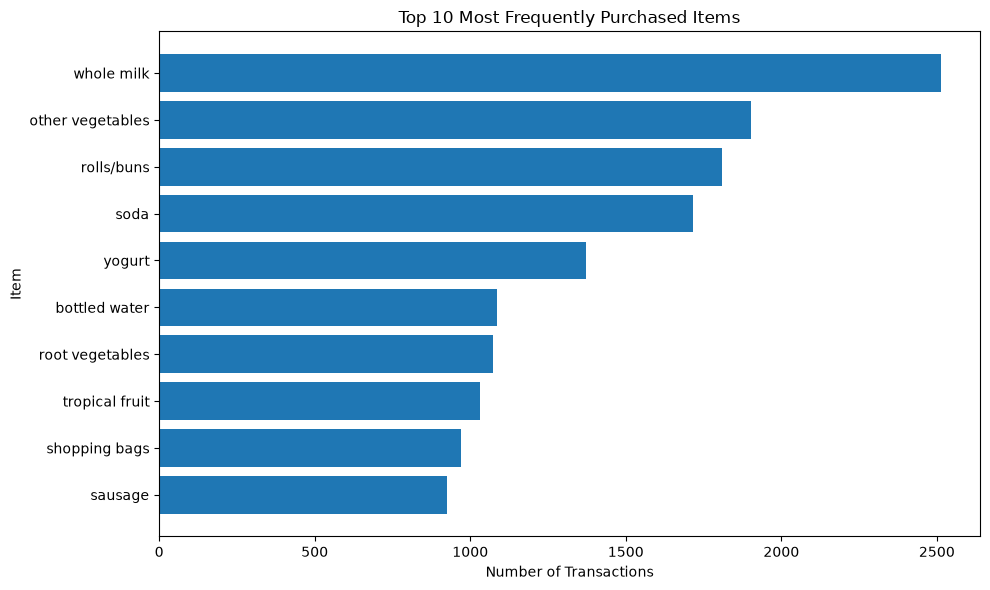

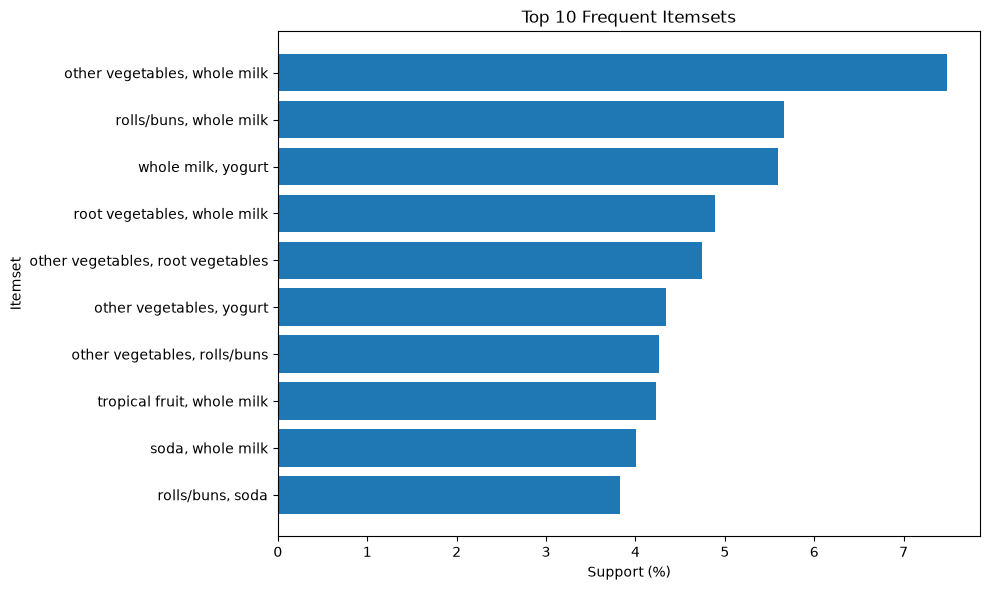

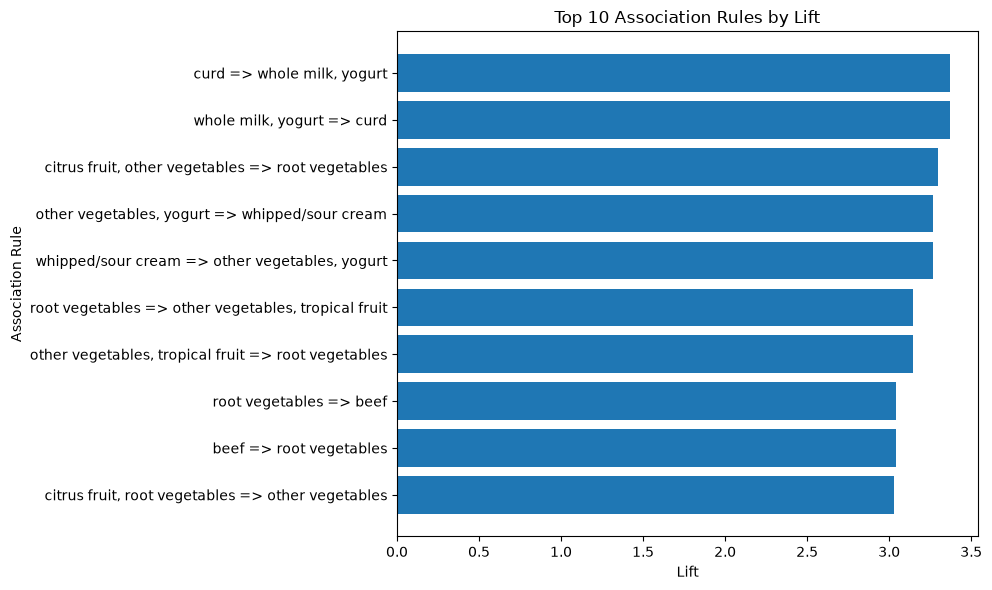

In [53]:
import matplotlib.pyplot as plt

# Figure 1: Top 10 individual items
items_df = pd.DataFrame(top_10, columns=["Item", "Count"])
plt.figure(figsize=(10, 6))
plt.barh(items_df["Item"][::-1], items_df["Count"][::-1])
plt.xlabel("Number of Transactions")
plt.ylabel("Item")
plt.title("Top 10 Most Frequently Purchased Items")
plt.tight_layout()
# Save the top 10 items figure
plt.savefig("top_10_items.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: Top 10 frequent itemsets
plot_itemsets = top_10_itemsets.copy()
plot_itemsets["Itemset"] = plot_itemsets["Itemset"].apply(lambda x: ", ".join(x))

plt.figure(figsize=(10, 6))
plt.barh(plot_itemsets["Itemset"][::-1], plot_itemsets["Support (%)"][::-1])
plt.xlabel("Support (%)")
plt.ylabel("Itemset")
plt.title("Top 10 Frequent Itemsets")
plt.tight_layout()
# Save the frequent itemsets figure
plt.savefig("top_10_itemsets.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: Top 10 association rules by lift
plot_rules = top_10_rules.copy()
plot_rules["Rule"] = (plot_rules["Antecedent"] + " => " + plot_rules["Consequent"])

plt.figure(figsize=(10, 6))
plt.barh(plot_rules["Rule"][::-1], plot_rules["lift"][::-1])
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Lift")
plt.tight_layout()
# Save the association rules figure
plt.savefig("top_10_rules.png", dpi=300, bbox_inches="tight")
plt.show()